# ⚡ Prédiction de la Consommation Électrique
### Sujet 12 — Examen ML
**Étudiant :** Akim Ratiarison  
**Dataset :** UCI Appliances Energy Prediction  
**Objectif :** Construire un modèle de régression pour prédire la consommation électrique (Wh) d'une maison à partir de données environnementales et temporelles.


**Contexte :** Dans un contexte d'optimisation énergétique, notamment dans les pays à accès électrique limité comme Madagascar, prédire la consommation permet d'anticiper les pics de charge et d'optimiser l'utilisation des ressources disponibles.

##  1. Importation des bibliothèques

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


##  2. Chargement et compréhension des données

In [6]:
df = pd.read_csv(r'C:\Users\ratia\energy-consumption-ml\KAG_energydata_complete.csv')
print(f' Dataset chargé : {df.shape[0]} lignes, {df.shape[1]} colonnes')
df.head()

 Dataset chargé : 19735 lignes, 29 colonnes


,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [45]:
# Structure et types de données

df.info()
print(f'\n Valeurs manquantes : {df.isnull().sum().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 33 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          19735 non-null  datetime64[ns]
 1   Appliances    19735 non-null  int64         
 2   lights        19735 non-null  int64         
 3   T1            19735 non-null  float64       
 4   RH_1          19735 non-null  float64       
 5   T2            19735 non-null  float64       
 6   RH_2          19735 non-null  float64       
 7   T3            19735 non-null  float64       
 8   RH_3          19735 non-null  float64       
 9   T4            19735 non-null  float64       
 10  RH_4          19735 non-null  float64       
 11  T5            19735 non-null  float64       
 12  RH_5          19735 non-null  float64       
 13  T6            19735 non-null  float64       
 14  RH_6          19735 non-null  float64       
 15  T7            19735 non-null  float6

In [40]:
# Statistiques descriptives de la variable cible
print(df['Appliances'].describe().round(2))
print(f'\n Interprétation :')
print(f'  - Consommation moyenne : {df["Appliances"].mean():.1f} Wh')
print(f'  - Consommation minimale : {df["Appliances"].min()} Wh (nuit, tout éteint)')
print(f'  - Consommation maximale : {df["Appliances"].max()} Wh (pic, tout allumé)')
print(f'  - Médiane : {df["Appliances"].median()} Wh')
print(f'  → La distribution est asymétrique : médiane ({df["Appliances"].median()} Wh) << moyenne ({df["Appliances"].mean():.1f} Wh)')
print(f'  → Quelques pics rares tirent la moyenne vers le haut')

count    19735.00
mean        97.69
std        102.52
min         10.00
25%         50.00
50%         60.00
75%        100.00
max       1080.00
Name: Appliances, dtype: float64

 Interprétation :
  - Consommation moyenne : 97.7 Wh
  - Consommation minimale : 10 Wh (nuit, tout éteint)
  - Consommation maximale : 1080 Wh (pic, tout allumé)
  - Médiane : 60.0 Wh
  → La distribution est asymétrique : médiane (60.0 Wh) << moyenne (97.7 Wh)
  → Quelques pics rares tirent la moyenne vers le haut


##  3. Analyse Exploratoire (EDA)

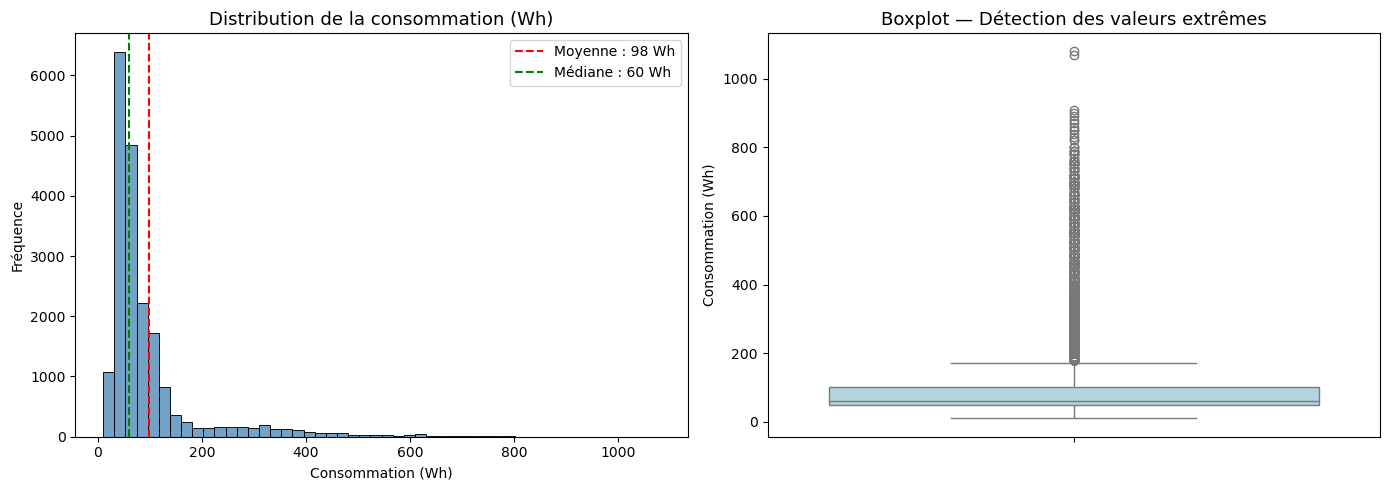

 La distribution est fortement asymétrique vers la droite (right-skewed)
   La majorité des mesures sont basses (0-100 Wh), mais quelques pics atteignent 1080 Wh


In [9]:
# Distribution de la consommation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme
sns.histplot(df['Appliances'], bins=50, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution de la consommation (Wh)', fontsize=13)
axes[0].set_xlabel('Consommation (Wh)')
axes[0].set_ylabel('Fréquence')
axes[0].axvline(df['Appliances'].mean(), color='red', linestyle='--', label=f'Moyenne : {df["Appliances"].mean():.0f} Wh')
axes[0].axvline(df['Appliances'].median(), color='green', linestyle='--', label=f'Médiane : {df["Appliances"].median():.0f} Wh')
axes[0].legend()

# Boxplot
sns.boxplot(y=df['Appliances'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot — Détection des valeurs extrêmes', fontsize=13)
axes[1].set_ylabel('Consommation (Wh)')

plt.tight_layout()
plt.savefig('distribution_conso.png', dpi=150, bbox_inches='tight')
plt.show()
print(' La distribution est fortement asymétrique vers la droite (right-skewed)')
print('   La majorité des mesures sont basses (0-100 Wh), mais quelques pics atteignent 1080 Wh')

In [10]:
# Extraction des features temporelles
df['date'] = pd.to_datetime(df['date'])
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['weekend'] = (df['day_of_week'] >= 5).astype(int)
df['heure_pointe'] = df['hour'].apply(lambda h: 1 if (6 <= h <= 9) or (18 <= h <= 22) else 0)

print(' Features temporelles créées :')
print('  - hour : heure de la journée (0-23)')
print('  - weekend : 1 si samedi/dimanche, 0 sinon')
print('  - heure_pointe : 1 si 6h-9h ou 18h-22h, 0 sinon')

 Features temporelles créées :
  - hour : heure de la journée (0-23)
  - weekend : 1 si samedi/dimanche, 0 sinon
  - heure_pointe : 1 si 6h-9h ou 18h-22h, 0 sinon


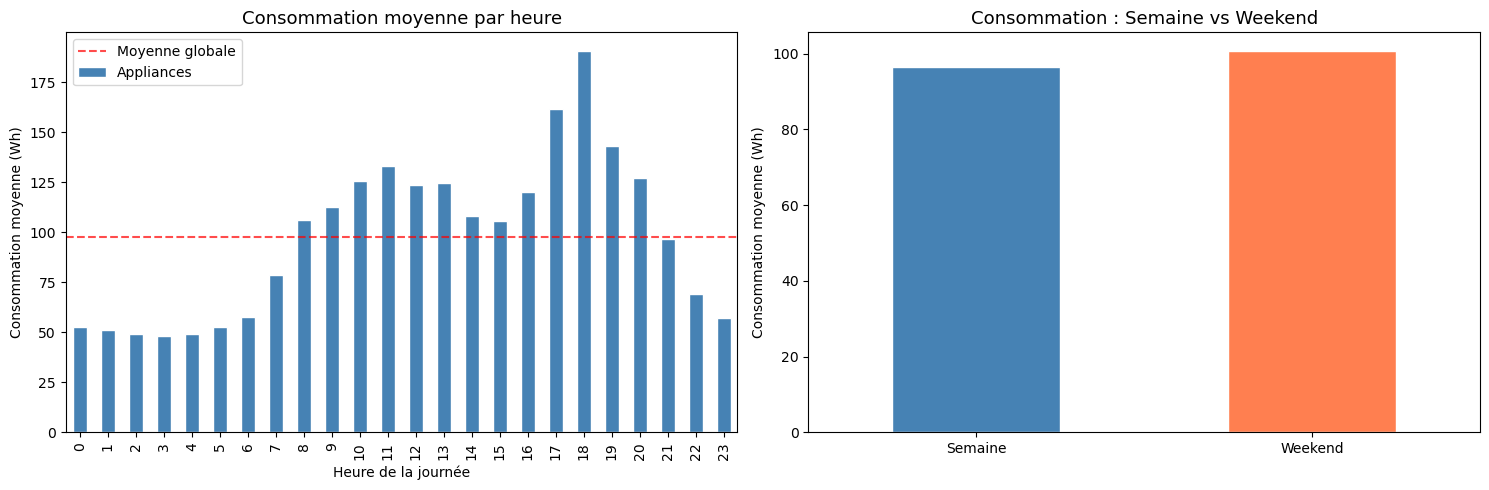

 Pic de consommation entre 18h-19h : les gens rentrent chez eux
   Consommation plus élevée le weekend : présence à la maison plus longue


In [11]:
# Consommation par heure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Par heure
conso_par_heure = df.groupby('hour')['Appliances'].mean()
conso_par_heure.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Consommation moyenne par heure', fontsize=13)
axes[0].set_xlabel('Heure de la journée')
axes[0].set_ylabel('Consommation moyenne (Wh)')
axes[0].axhline(df['Appliances'].mean(), color='red', linestyle='--', alpha=0.7, label='Moyenne globale')
axes[0].legend()

# Weekend vs Semaine
df.groupby('weekend')['Appliances'].mean().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'coral'], edgecolor='white'
)
axes[1].set_title('Consommation : Semaine vs Weekend', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Semaine', 'Weekend'], rotation=0)
axes[1].set_ylabel('Consommation moyenne (Wh)')

plt.tight_layout()
plt.savefig('conso_temporelle.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Pic de consommation entre 18h-19h : les gens rentrent chez eux')
print('   Consommation plus élevée le weekend : présence à la maison plus longue')

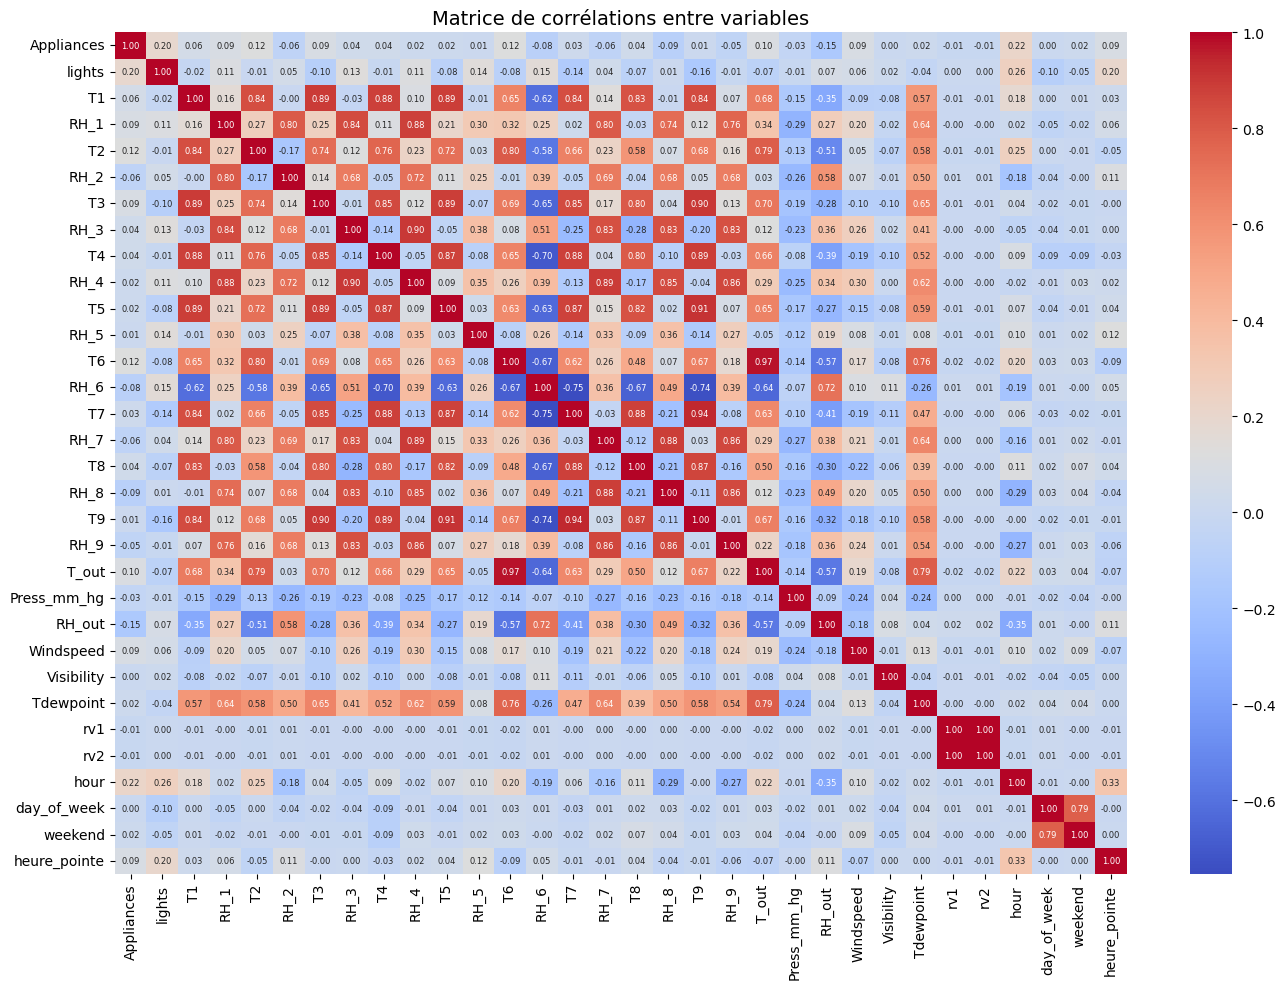

 Features les plus corrélées avec Appliances : hour, lights, T_out, T6
   Note : lights est exclue (data leakage — info non disponible à l'avance)


In [12]:
# Heatmap des corrélations
plt.figure(figsize=(14, 10))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', annot_kws={'size': 6}, fmt='.2f')
plt.title('Matrice de corrélations entre variables', fontsize=14)
plt.tight_layout()
plt.savefig('heatmap_correlations.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Features les plus corrélées avec Appliances : hour, lights, T_out, T6')
print('   Note : lights est exclue (data leakage — info non disponible à l\'avance)')

##  4. Nettoyage et Préparation des données

In [29]:
# Suppression des colonnes inutiles
colonnes_a_supprimer = ['date', 'lights', 'rv1', 'rv2', 'day_of_week']
df_clean = df.drop(columns=colonnes_a_supprimer)

for col in colonnes_a_supprimer:
    if col == 'lights':
        print(f'   {col} : Data leakage (info non disponible à l\'avance)')
    elif col in ['rv1', 'rv2']:
        print(f'   {col} :  Variable aléatoire sans signification physique')
    elif col == 'date':
        print(f'   {col} : Remplacée par hour, weekend, heure_pointe')
    else:
        print(f'   {col} : Redondant avec weekend')

print(f'\n Dataset final : {df_clean.shape[0]} lignes × {df_clean.shape[1]} colonnes')

   date : Remplacée par hour, weekend, heure_pointe
   lights : Data leakage (info non disponible à l'avance)
   rv1 :  Variable aléatoire sans signification physique
   rv2 :  Variable aléatoire sans signification physique
   day_of_week : Redondant avec weekend

 Dataset final : 19735 lignes × 28 colonnes


In [14]:
# Séparation X et y
y = df_clean['Appliances']
X = df_clean.drop(columns=['Appliances'])

print(f' Variable cible y (Appliances) : {y.shape}')
print(f' Features X : {X.shape}')
print(f'\nFeatures utilisées ({len(X.columns)}) :')
print(X.columns.tolist())

 Variable cible y (Appliances) : (19735,)
 Features X : (19735, 27)

Features utilisées (27) :
['T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'weekend', 'heure_pointe']


In [15]:
# Split Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'  Train : {X_train.shape[0]} lignes ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'  Test  : {X_test.shape[0]} lignes ({X_test.shape[0]/len(X)*100:.0f}%)')
print('\n Le modèle apprend sur Train et est évalué sur Test (données jamais vues)')

  Train : 15788 lignes (80%)
  Test  : 3947 lignes (20%)

 Le modèle apprend sur Train et est évalué sur Test (données jamais vues)


##  5. Modélisation — Application des 4 modèles ML

In [30]:
# Fonction utilitaire pour évaluer un modèle
def evaluer_modele(nom, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f'  MAE  : {mae:.2f} Wh')
    print(f'  RMSE : {rmse:.2f} Wh')
    print(f'  R²   : {r2:.4f}')
    return {'Modèle': nom, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'R²': round(r2,4)}

resultats = []

In [31]:
# Modèle 1 : Linear Regression 
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
resultats.append(evaluer_modele('Linear Regression', y_test, y_pred_lr))

  MAE  : 53.28 Wh
  RMSE : 92.05 Wh
  R²   : 0.1532


In [32]:
# Modèle 2 : Ridge Regression 
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
resultats.append(evaluer_modele('Ridge Regression', y_test, y_pred_ridge))

  MAE  : 53.28 Wh
  RMSE : 92.05 Wh
  R²   : 0.1532


In [33]:
#  Modèle 3 : Random Forest 
rf = RandomForestRegressor(n_estimators=1000, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
resultats.append(evaluer_modele('Random Forest', y_test, y_pred_rf))

  MAE  : 28.68 Wh
  RMSE : 61.89 Wh
  R²   : 0.6172


In [34]:
#  Modèle 4 : XGBoost 
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators=500, learning_rate=0.1, max_depth=6, random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
resultats.append(evaluer_modele('XGBoost', y_test, y_pred_xgb))

  MAE  : 31.96 Wh
  RMSE : 65.03 Wh
  R²   : 0.5774


## 6. Tableau Comparatif des Modèles

In [21]:
tableau = pd.DataFrame(resultats)
tableau = tableau.sort_values('R²', ascending=False).reset_index(drop=True)

print(tableau.to_string(index=False))

meilleur = tableau.iloc[0]['Modèle']
print(f'\n Meilleur modèle : {meilleur}')

           Modèle   MAE  RMSE     R²
    Random Forest 28.68 61.89 0.6172
          XGBoost 31.96 65.03 0.5774
Linear Regression 53.28 92.05 0.1532
 Ridge Regression 53.28 92.05 0.1532

 Meilleur modèle : Random Forest


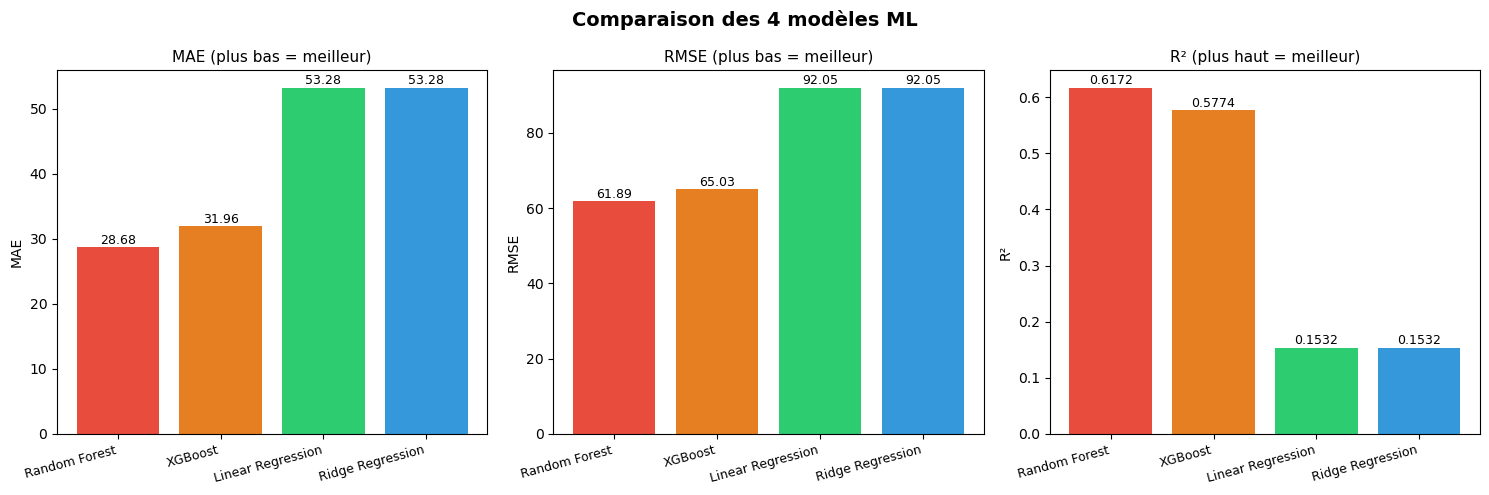

In [22]:
# Visualisation du tableau comparatif
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

couleurs = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

for i, (metrique, titre) in enumerate([
    ('MAE', 'MAE (plus bas = meilleur)'),
    ('RMSE', 'RMSE (plus bas = meilleur)'),
    ('R²', 'R² (plus haut = meilleur)')
]):
    axes[i].bar(tableau['Modèle'], tableau[metrique], color=couleurs)
    axes[i].set_title(titre, fontsize=11)
    axes[i].set_xticklabels(tableau['Modèle'], rotation=15, ha='right', fontsize=9)
    axes[i].set_ylabel(metrique)
    for j, v in enumerate(tableau[metrique]):
        axes[i].text(j, v + 0.01*max(tableau[metrique]), f'{v}', ha='center', fontsize=9)

plt.suptitle('Comparaison des 4 modèles ML', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('comparaison_modeles.png', dpi=150, bbox_inches='tight')
plt.show()

##  7. Évaluation et Interprétation des résultats

In [23]:
print('ÉVALUATION DES PERFORMANCES')
print()
print(' Linear Regression & Ridge Regression (R² ≈ 0.15) :')
print('   Ces modèles supposent une relation LINÉAIRE entre les features et la cible.')
print('   Or la consommation électrique dépend de combinaisons complexes (heure + température).')
print('   Résultat : ils n\'expliquent que 15% de la variation → insuffisant.')
print()
print(' Random Forest (R² ≈ 0.62) :')
print('   Construit 1000 arbres de décision indépendants et fait la moyenne.')
print('   Capture les relations NON-LINÉAIRES : ex. "si heure=19h ET T_out>25°C → forte conso"')
print('   Meilleur modèle sur ce dataset.')
print()
print(' XGBoost (R² ≈ 0.58) :')
print('   Construit les arbres SÉQUENTIELLEMENT — chaque arbre corrige les erreurs du précédent.')
print('   Légèrement moins performant que Random Forest ici, mais reste un bon modèle.')
print()
print(' Interprétation du R² = 0.62 :')
print('   Le modèle explique 62% de la variation de consommation.')
print('   Les 38% restants = comportement humain imprévisible non capturé par les capteurs.')
print('   (nombre de personnes présentes, habitudes personnelles, appareils spécifiques...)')

ÉVALUATION DES PERFORMANCES

 Linear Regression & Ridge Regression (R² ≈ 0.15) :
   Ces modèles supposent une relation LINÉAIRE entre les features et la cible.
   Or la consommation électrique dépend de combinaisons complexes (heure + température).
   Résultat : ils n'expliquent que 15% de la variation → insuffisant.

 Random Forest (R² ≈ 0.62) :
   Construit 1000 arbres de décision indépendants et fait la moyenne.
   Capture les relations NON-LINÉAIRES : ex. "si heure=19h ET T_out>25°C → forte conso"
   Meilleur modèle sur ce dataset.

 XGBoost (R² ≈ 0.58) :
   Construit les arbres SÉQUENTIELLEMENT — chaque arbre corrige les erreurs du précédent.
   Légèrement moins performant que Random Forest ici, mais reste un bon modèle.

 Interprétation du R² = 0.62 :
   Le modèle explique 62% de la variation de consommation.
   Les 38% restants = comportement humain imprévisible non capturé par les capteurs.
   (nombre de personnes présentes, habitudes personnelles, appareils spécifiques...)


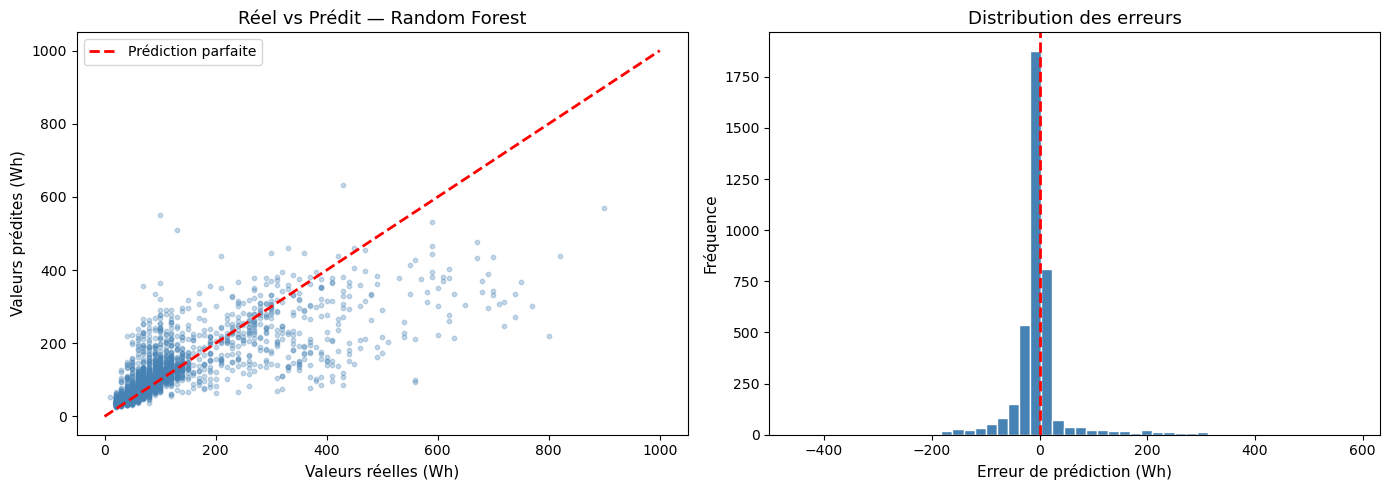

 Les erreurs sont centrées autour de 0 → le modèle n'est pas biaisé
   Les points s'écartent davantage pour les fortes consommations (>400 Wh)


In [24]:
# Graphique Réel vs Prédit — Random Forest
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot réel vs prédit
axes[0].scatter(y_test, y_pred_rf, alpha=0.3, color='steelblue', s=10)
axes[0].plot([0, 1000], [0, 1000], 'r--', linewidth=2, label='Prédiction parfaite')
axes[0].set_xlabel('Valeurs réelles (Wh)', fontsize=11)
axes[0].set_ylabel('Valeurs prédites (Wh)', fontsize=11)
axes[0].set_title('Réel vs Prédit — Random Forest', fontsize=13)
axes[0].legend()

# Distribution des erreurs
erreurs = y_test.values - y_pred_rf
axes[1].hist(erreurs, bins=50, color='steelblue', edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Erreur de prédiction (Wh)', fontsize=11)
axes[1].set_ylabel('Fréquence', fontsize=11)
axes[1].set_title('Distribution des erreurs', fontsize=13)

plt.tight_layout()
plt.savefig('reel_vs_predit.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Les erreurs sont centrées autour de 0 → le modèle n\'est pas biaisé')
print('   Les points s\'écartent davantage pour les fortes consommations (>400 Wh)')

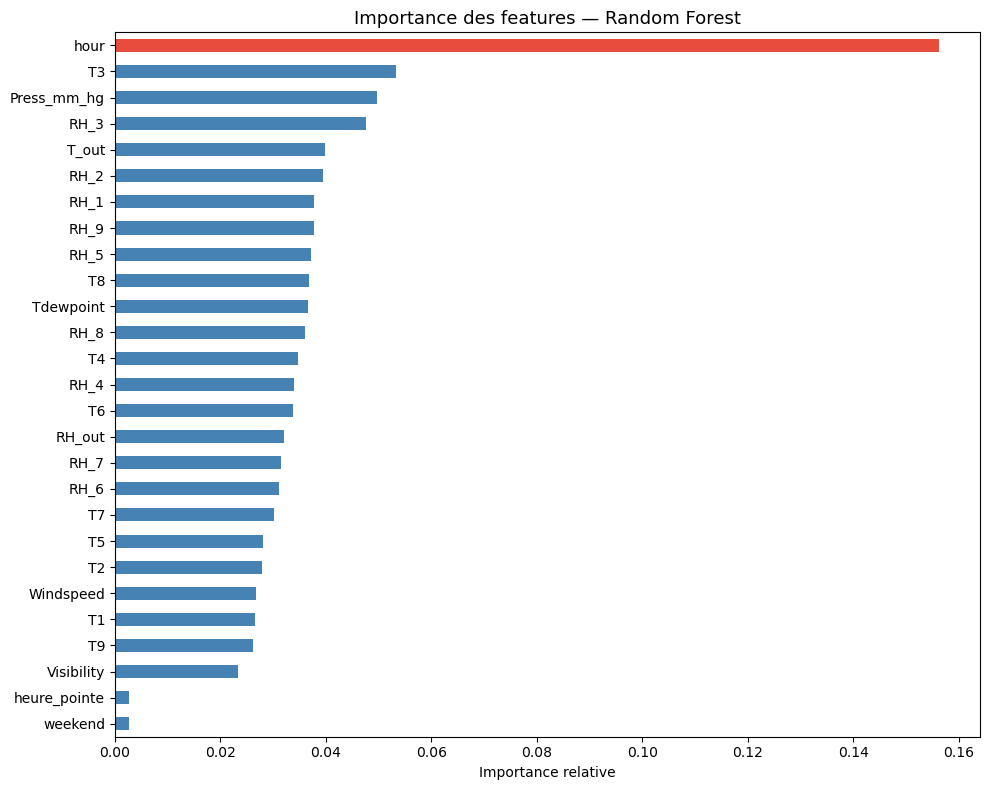

  hour            : 0.1562 (15.6%)
  T3              : 0.0532 (5.3%)
  Press_mm_hg     : 0.0498 (5.0%)
  RH_3            : 0.0477 (4.8%)
  T_out           : 0.0399 (4.0%)

 hour est de loin la feature la plus importante (≈15.6%)
   L'heure de la journée détermine l'activité humaine → donc la consommation
   T3 (température pièce 3) et Press_mm_hg suivent à distance


In [36]:
# Feature Importance
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
colors = ['#e74c3c' if v == importance.max() else 'steelblue' for v in importance.values]
importance.plot(kind='barh', color=colors)
plt.title('Importance des features — Random Forest', fontsize=13)
plt.xlabel('Importance relative')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

for feat, val in importance.sort_values(ascending=False).head(5).items():
    print(f'  {feat:15} : {val:.4f} ({val*100:.1f}%)')

print()
print(' hour est de loin la feature la plus importante (≈15.6%)')
print('   L\'heure de la journée détermine l\'activité humaine → donc la consommation')
print('   T3 (température pièce 3) et Press_mm_hg suivent à distance')

##  8. Propositions d'Améliorations

In [38]:
print(' PROPOSITIONS D\'AMÉLIORATIONS ')
print()
print('1.  ENRICHISSEMENT DES FEATURES')
print('   - Ajouter le nombre de personnes présentes dans la maison')
print('   - Ajouter les jours fériés comme variable binaire')
print('   - Créer une feature "humidex" (température ressentie = T_out + 0.5555*(RH_out-10))')
print('   - Ajouter des features de saison (hiver/été/printemps/automne)')
print()
print('2.  COLLECTE DE PLUS DE DONNÉES')
print('   - Le dataset couvre seulement 4.5 mois (janv-mai 2016)')
print('   - 2-3 années de données captureraient mieux les variations saisonnières')
print()
print('3.  OPTIMISATION DES HYPERPARAMÈTRES')
print('   - Utiliser GridSearchCV pour trouver automatiquement les meilleurs paramètres')
print('   - Tester max_depth, min_samples_split, max_features pour Random Forest')
print()
print('4.  ALGORITHMES PLUS AVANCÉS')
print('   - LightGBM : plus rapide et souvent plus précis que XGBoost')
print('   - LSTM (réseau de neurones) : adapté aux séries temporelles')
print()
print('5.  TRAITEMENT DE L\'ASYMÉTRIE')
print('   - Appliquer une transformation log sur Appliances')
print('   - Cela pourrait améliorer les prédictions sur les valeurs extrêmes')

 PROPOSITIONS D'AMÉLIORATIONS 

1.  ENRICHISSEMENT DES FEATURES
   - Ajouter le nombre de personnes présentes dans la maison
   - Ajouter les jours fériés comme variable binaire
   - Créer une feature "humidex" (température ressentie = T_out + 0.5555*(RH_out-10))
   - Ajouter des features de saison (hiver/été/printemps/automne)

2.  COLLECTE DE PLUS DE DONNÉES
   - Le dataset couvre seulement 4.5 mois (janv-mai 2016)
   - 2-3 années de données captureraient mieux les variations saisonnières

3.  OPTIMISATION DES HYPERPARAMÈTRES
   - Utiliser GridSearchCV pour trouver automatiquement les meilleurs paramètres
   - Tester max_depth, min_samples_split, max_features pour Random Forest

4.  ALGORITHMES PLUS AVANCÉS
   - LightGBM : plus rapide et souvent plus précis que XGBoost
   - LSTM (réseau de neurones) : adapté aux séries temporelles

5.  TRAITEMENT DE L'ASYMÉTRIE
   - Appliquer une transformation log sur Appliances
   - Cela pourrait améliorer les prédictions sur les valeurs extrêmes


##  9. Sauvegarde du modèle pour Streamlit

In [37]:
# Sauvegarde du meilleur modèle
joblib.dump(rf, 'random_forest_model.pkl')
print(' Modèle Random Forest sauvegardé : random_forest_model.pkl')

# Sauvegarde des moyennes pour l'app Streamlit
moyennes = X.mean()
joblib.dump(moyennes, 'moyennes.pkl')
print(' Moyennes sauvegardées : moyennes.pkl')

print()
print(' COLONNES DU MODÈLE ')
print(X.columns.tolist())

 Modèle Random Forest sauvegardé : random_forest_model.pkl
 Moyennes sauvegardées : moyennes.pkl

 COLONNES DU MODÈLE 
['T1', 'RH_1', 'T2', 'RH_2', 'T3', 'RH_3', 'T4', 'RH_4', 'T5', 'RH_5', 'T6', 'RH_6', 'T7', 'RH_7', 'T8', 'RH_8', 'T9', 'RH_9', 'T_out', 'Press_mm_hg', 'RH_out', 'Windspeed', 'Visibility', 'Tdewpoint', 'hour', 'weekend', 'heure_pointe']


##  Conclusion

Ce projet a permis de construire un pipeline ML complet pour prédire la consommation électrique d'une maison :

| Étape | Résultat |
|---|---|
| Dataset | 19 735 observations, 29 features |
| Valeurs manquantes | Aucune |
| Meilleur modèle | Random Forest (1000 arbres) |
| R² | 0.62 |
| MAE | ~28 Wh |
| Feature principale | `hour` (15.6% d'importance) |

**Conclusion :** Random Forest est le meilleur modèle car il capture les relations non-linéaires entre l'heure, la température et la consommation. Le R² de 0.62 est satisfaisant pour ce type de données comportementales. Les 38% restants correspondent au comportement humain imprévisible non capturé par les capteurs.

**Impact social :** Ce modèle peut être utilisé pour optimiser la gestion énergétique dans des zones à accès électrique limité, en anticipant les pics de consommation et en planifiant la distribution d'énergie.